In [1]:
# import pandas as pd

# df = pd.read_csv('not filtered toloka results.csv')

# df = pd.DataFrame({
#     # "title": df["INPUT:title"].tolist(),
#  "img_path": df["INPUT:imagepath"].tolist(),
#  "res1": df["OUTPUT:result1"].tolist(),
#  "res2": df["OUTPUT:result2"].tolist(),
#  "res3": df["OUTPUT:result3"].tolist(),
#  "res4": df["OUTPUT:result4"].tolist()})

# df = df.dropna()


In [2]:
import pandas as pd

d_df = pd.read_csv('dataframes/not_filtred_data.csv')

df = pd.DataFrame({
    # "title": df["INPUT:title"].tolist(),
 "photo_url": d_df["INPUT:imagepath"].tolist(),
 "res1": d_df["OUTPUT:result1"].tolist(),
 "res2": d_df["OUTPUT:result2"].tolist(),
 "res3": d_df["OUTPUT:result3"].tolist(),
 "res4": d_df["OUTPUT:result4"].tolist()})

df = df.dropna()


In [3]:
func = lambda item: [
                     item["res1"],
                     item["res2"],
                     item["res3"],
                     item["res4"],
                    ]

df["result_list"] = df.apply(func, axis=1)

In [4]:
df.to_csv('dataframes/llava_df.csv', index=False)

In [3]:
import pandas as pd



# Function to calculate mean values for each img_path
def calculate_mean_values(df):
    # Group by img_path and calculate mean for each group
    grouped_df = df.groupby("img_path").mean()
    
    # Rename columns to match the expected output
    grouped_df.columns = ["mos1", "mos2", "mos3", "mos4"]
    
    # Reset index to make img_path a column again
    grouped_df.reset_index(inplace=True)
    
    return grouped_df

# Add new columns with mean values
mean_values_df = calculate_mean_values(df)

# # Merge the original DataFrame with the mean values DataFrame
df = df.merge(mean_values_df, on="img_path", how="left")
# df = df.drop_duplicates(subset=["img_path"])
# print(df)

In [6]:
df.drop_duplicates('img_path')

,img_path,res1,res2,res3,res4,mos1,mos2,mos3,mos4
0,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,1.0,1.0,1.0,1.0
1,https://storage.yandexcloud.net/svg-images-fir...,5,2,1,1,5.0,3.5,3.0,3.0
2,https://storage.yandexcloud.net/svg-images-fir...,1,1,3,1,1.0,1.0,2.0,1.0
3,https://storage.yandexcloud.net/svg-images-fir...,5,5,3,5,5.0,4.0,3.0,4.0
4,https://storage.yandexcloud.net/svg-images-fir...,2,2,1,1,3.5,3.5,3.0,3.0
...,...,...,...,...,...,...,...,...,...
32126,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,1.0,1.0,1.0,1.0
32127,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,1.0,1.0,1.0,1.0
32129,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,1.0,1.0,1.0,1.0
32135,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,2.5,2.5,2.5,2.5


In [7]:
df[df["img_path"] == "https://storage.yandexcloud.net/svg-images-first-pack/goodcibo00AbstractedPeerInclusionsvg.png"]

,img_path,res1,res2,res3,res4,mos1,mos2,mos3,mos4
17423,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,1.5,2.0,2.0,2.0


#### Попробуем получить какую-то человеческую оценку фотографий по имеющимся данным

Я понимаю что это вообще далеко от математики, но распределение похоже на нормальное - значит теплится надежда, что по итогу получится обучить на этом модельку

<Axes: >

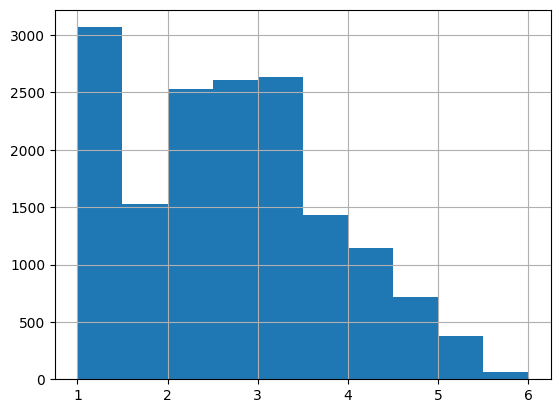

In [8]:
df.iloc[:, 6:].mean(1).hist()

In [9]:
df["final_mos"] = df.iloc[:, 6:].mean(1)

In [10]:
!mkdir dataframes

mkdir: cannot create directory ‘dataframes’: File exists


In [11]:
df.rename(columns={"img_path": "photo_url"}).to_csv("dataframes/parsed_toloka_dataset.csv", index=False)

In [12]:
print(pd.read_csv("dataframes/loaded_parsed_toloka_dataset.csv").head(3))

                                           photo_url  res1  res2  res3  res4  \
0  https://storage.yandexcloud.net/svg-images-fir...     1     1     1     1   
1  https://storage.yandexcloud.net/svg-images-fir...     5     2     1     1   
2  https://storage.yandexcloud.net/svg-images-fir...     1     1     3     1   

   mos1  mos2  mos3  mos4  final_mos  \
0   1.0   1.0   1.0   1.0   1.000000   
1   5.0   3.5   3.0   3.0   3.166667   
2   1.0   1.0   2.0   1.0   1.333333   

                                            img_path  
0  /mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...  
1  /mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...  
2  /mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...  


# Vector-images-quality-assessment-using-deep-learning

### Задачи (расположены поэтапно):
1) Сбор векторных изображений – parsers/main.py
2) Переименование и конвертация svg изображений в png расширение -- converting.py.
3) Некая статистика по разрешениям изобаржений и дальнейшая нормализация разрешений -- stata.py
4) Отчистка от дубликатов и нежелательных изображений -- clearing.py
5) Взятие эмбеддингов -- clipBlip/clipModel
6) Кластеризация -- clustering_models.py
7) Взятие описаний к изображениям -- clipBlip/blipModel

### Остальные файлы:
_paths.txt_ - для прописывания путей

_save_read.py_ - для храненения таких сущностей, как словари с очищенными/неочищенными эмбеддингами, получившиеся резульаты  кластеризации и т.д.

_visualization.py_ - функции для визуализации некоторых результатах.


### Сборка пайплайна:

#### Установка зависимостей:
```bash
conda create -n "nr_iqa" python=3.9
pip install -r base_requirements.txt
```

1) Прогоняете тетрадку 1_parse_data
2) Запускаете скрипт 2_load_data.py

Теперь ваши данные загружены в папку: toloka_parsed_data
Также по пути: "dataframes/loaded_parsed_toloka_dataset.csv" - у вас теперь есть датасет вот такой структуры:

```
                                               title  \
0    a black and white drawing of a man sitting o...   
1          a banana, lemon and a blueberry are shown   
2        a black background with a white clock on it   

                                           photo_url  res1  res2  res3  res4  \
0  https://storage.yandexcloud.net/svg-images-fir...   1.0   1.0   1.0   1.0   
1  https://storage.yandexcloud.net/svg-images-fir...   5.0   2.0   1.0   1.0   
2  https://storage.yandexcloud.net/svg-images-fir...   1.0   1.0   3.0   1.0   

   mos1  mos2  mos3  mos4  final_mos  \
0   1.0   1.0   1.0   1.0      1.000   
1   5.0   3.5   3.0   3.0      3.625   
2   1.0   1.0   2.0   1.0      1.250   

                                            img_path  
0  /mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...  
1  /mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...  
2  /mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...  

```


In [1]:
import pandas as pd

fraud_df = pd.read_csv('ai_annotation/dataframes/llava_fraud_answers.csv')
ranking_df = pd.read_csv('ai_annotation/dataframes/llava_ranking_images.csv')

<Axes: >

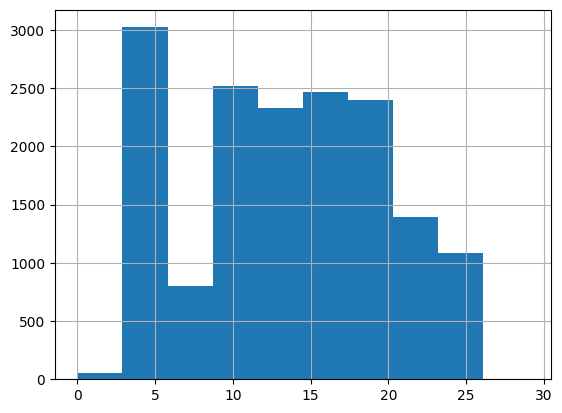

In [2]:
import re


def extract_item_from_text(item):
    pattern = r'\[(?:\d+(?:,\s*\d+)*)\]'
    matches = re.findall(pattern, item)
    if matches:
        return sum(eval(matches[0]))
    else:
        return 10

ranking_df['llava_rank'] = ranking_df.answer_llava.apply(extract_item_from_text)
ranking_df['llava_rank'].hist()

In [3]:
preprocess_fraud = lambda item: "".join([char for char in item.lower().replace("'\'", "") if char.isalpha()])

fraud_df['answer_llava_cleared'] = fraud_df.answer_llava.apply(preprocess_fraud)
fraud_df.answer_llava_cleared.value_counts()[:15]

datamarkuperror               13560
notsure                        8776
safe                           7959
fraud                          1540
                                 12
error                             9
unsafe                            7
安全                                3
aestheticbeauty                   3
fault                             3
inconsistent                      2
secure                            2
nonsure                           2
theoutputisdatamarkuperror        2
incomplete                        2
Name: answer_llava_cleared, dtype: int64

In [4]:
def get_fraud_label(item):
    if item == 'datamarkuperror':
        return 1
    elif item == 'notsure':
        return 0
    elif item == 'fraud':
        return 1
    elif item == 'safe':
        return 0
    else:
        return 0

fraud_df['label'] = fraud_df.answer_llava_cleared.apply(get_fraud_label)
fraud_df = fraud_df[fraud_df['label'] == 0]

In [5]:
fraud_df['markup_rank'] = fraud_df.result_list.apply(lambda item: sum(eval(item)))

In [6]:
grouped_df = fraud_df.groupby("img_path")
mean_val_df = grouped_df.markup_rank.mean()
mean_val_dict = mean_val_df.to_dict()

In [7]:
ranking_df['markup_mos'] = ranking_df.img_path.apply(lambda item: mean_val_dict.get(item, None))
ranking_df

,photo_url,res1,res2,res3,res4,result_list,img_path,answer_llava,llava_rank,markup_mos
0,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,"[1, 1, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[3, 2, 5, 6]",16,4.0
1,https://storage.yandexcloud.net/svg-images-fir...,5,2,1,1,"[5, 2, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[2, 4, 3, 3]",12,14.5
2,https://storage.yandexcloud.net/svg-images-fir...,1,1,3,1,"[1, 1, 3, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[1, 1, 1, 1]",4,5.0
3,https://storage.yandexcloud.net/svg-images-fir...,5,5,3,5,"[5, 5, 3, 5]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,The image you provided seems to be a checkered...,10,NaN
4,https://storage.yandexcloud.net/svg-images-fir...,2,2,1,1,"[2, 2, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[4, 2, 3, 5]",14,13.0
...,...,...,...,...,...,...,...,...,...,...
16060,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,"[1, 1, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[5, 3, 2, 5]",15,4.0
16061,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,"[1, 1, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[5, 5, 4, 5]",19,4.0
16062,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,"[1, 1, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"```\n[4, 4, 4, 5]\n```",17,4.0
16063,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,"[1, 1, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[1, 1, 4, 1]",7,NaN


In [13]:
def get_final_mos(item1, item2):
    if pd.isna(item2):
        return item1
    else:
        return sum([item1, item2]) / 2


final_mos = [get_final_mos(item1, item2) for item1, item2
             in zip(ranking_df.llava_rank.tolist(), ranking_df.markup_mos.tolist())]
final_mos

[10.0,
 13.25,
 4.5,
 10,
 13.5,
 6.5,
 4.5,
 18.0,
 11.5,
 11.5,
 15.5,
 4,
 17.0,
 4,
 18.0,
 10,
 10.5,
 20.0,
 16.0,
 9.0,
 14,
 8.0,
 14.5,
 13.5,
 24,
 12.0,
 8.0,
 18.0,
 13.0,
 8.5,
 11.0,
 4,
 6.5,
 7.0,
 8.0,
 14,
 18.0,
 16.0,
 4.5,
 7,
 22,
 8.5,
 10.5,
 10.0,
 13.5,
 18.0,
 18,
 9.0,
 12.5,
 9.5,
 10.5,
 4.75,
 5.5,
 10.0,
 4.0,
 13,
 10,
 12.0,
 22.0,
 10,
 11.0,
 10.0,
 24,
 4.0,
 4,
 11.5,
 17,
 17.5,
 12,
 17,
 16,
 18.0,
 18.5,
 10.5,
 10.25,
 20.0,
 22.0,
 17.0,
 17.25,
 10.25,
 6.5,
 10.0,
 11.5,
 14.5,
 12.0,
 17.5,
 22.0,
 15.0,
 5,
 12.0,
 15,
 19,
 7.25,
 9,
 16,
 11.0,
 14.0,
 16,
 4,
 13.25,
 17.5,
 4.0,
 6.5,
 10.5,
 17.5,
 13.25,
 13.5,
 11.0,
 16.0,
 15.0,
 6.5,
 7,
 11.5,
 16.75,
 9,
 12.5,
 8.5,
 5.0,
 10.0,
 11.0,
 7.5,
 13.0,
 15,
 8.5,
 17.0,
 14.5,
 14,
 15.0,
 22.0,
 15.0,
 7.0,
 8.5,
 10.5,
 14.0,
 10.5,
 12,
 10.5,
 11,
 15.25,
 13.5,
 14,
 9,
 12,
 4.0,
 13,
 11,
 8.0,
 9.0,
 4,
 12.0,
 5.0,
 9.0,
 4.0,
 11.25,
 17.0,
 6.5,
 16.0,
 10.5,
 8.0,
 7.

In [14]:
ranking_df['final_mos'] = final_mos


In [15]:
ranking_df

,photo_url,res1,res2,res3,res4,result_list,img_path,answer_llava,llava_rank,markup_mos,final_mos
0,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,"[1, 1, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[3, 2, 5, 6]",16,4.0,10.00
1,https://storage.yandexcloud.net/svg-images-fir...,5,2,1,1,"[5, 2, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[2, 4, 3, 3]",12,14.5,13.25
2,https://storage.yandexcloud.net/svg-images-fir...,1,1,3,1,"[1, 1, 3, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[1, 1, 1, 1]",4,5.0,4.50
3,https://storage.yandexcloud.net/svg-images-fir...,5,5,3,5,"[5, 5, 3, 5]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,The image you provided seems to be a checkered...,10,NaN,10.00
4,https://storage.yandexcloud.net/svg-images-fir...,2,2,1,1,"[2, 2, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[4, 2, 3, 5]",14,13.0,13.50
...,...,...,...,...,...,...,...,...,...,...,...
16060,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,"[1, 1, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[5, 3, 2, 5]",15,4.0,9.50
16061,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,"[1, 1, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[5, 5, 4, 5]",19,4.0,11.50
16062,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,"[1, 1, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"```\n[4, 4, 4, 5]\n```",17,4.0,10.50
16063,https://storage.yandexcloud.net/svg-images-fir...,1,1,1,1,"[1, 1, 1, 1]",/mnt/nvme0/jupyter-kazancev.danil7@wb-2ede4/pr...,"[1, 1, 4, 1]",7,NaN,7.00


In [17]:
ranking_df.to_csv("dataframes/loaded_parsed_toloka_dataset.csv", index=False)